# Predicting the Price of Used Car using Brand, Model, Year, Mileage and Engine Size:

## Importing the relevant libraries

In [83]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns
sns.set()

## Loading the raw data

In [84]:
raw_data = pd.read_csv('1.04. Real-life example.csv')
raw_data.head()
raw_data['Model'].nunique()


312

## Preprocessing

### Exploring the descriptive statistics of the variables

In [85]:
raw_data.describe(include='all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
count,4345,4173.000000,4345,4345.000000,4195.000000,4345,4345,4345.000000,4345
unique,7,NaN,6,NaN,NaN,4,2,NaN,312
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN,E-Class
freq,936,NaN,1649,NaN,NaN,2019,3947,NaN,199
mean,NaN,19418.746935,NaN,161.237284,2.790734,NaN,NaN,2006.550058,NaN
std,NaN,25584.242620,NaN,105.705797,5.066437,NaN,NaN,6.719097,NaN
min,NaN,600.000000,NaN,0.000000,0.600000,NaN,NaN,1969.000000,NaN
25%,NaN,6999.000000,NaN,86.000000,1.800000,NaN,NaN,2003.000000,NaN
50%,NaN,11500.000000,NaN,155.000000,2.200000,NaN,NaN,2008.000000,NaN
75%,NaN,21700.000000,NaN,230.000000,3.000000,NaN,NaN,2012.000000,NaN


### Determining the variables of interest

In [86]:
data_w_nan = raw_data[["Price","EngineV"]]
data_w_nan

,Price,EngineV
0,4200.0,2.0
1,7900.0,2.9
2,13300.0,5.0
3,23000.0,4.2
4,18300.0,2.0
...,...,...
4340,125000.0,3.0
4341,6500.0,3.5
4342,8000.0,2.0
4343,14200.0,NaN


### Dealing with missing values

In [87]:
data = raw_data.dropna(axis=0)

In [88]:
data.describe(include='all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
count,4025,4025.000000,4025,4025.000000,4025.000000,4025,4025,4025.000000,4025
unique,7,NaN,6,NaN,NaN,4,2,NaN,306
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN,E-Class
freq,880,NaN,1534,NaN,NaN,1861,3654,NaN,188
mean,NaN,19552.308065,NaN,163.572174,2.764586,NaN,NaN,2006.379627,NaN
std,NaN,25815.734988,NaN,103.394703,4.935941,NaN,NaN,6.695595,NaN
min,NaN,600.000000,NaN,0.000000,0.600000,NaN,NaN,1969.000000,NaN
25%,NaN,6999.000000,NaN,90.000000,1.800000,NaN,NaN,2003.000000,NaN
50%,NaN,11500.000000,NaN,158.000000,2.200000,NaN,NaN,2007.000000,NaN
75%,NaN,21900.000000,NaN,230.000000,3.000000,NaN,NaN,2012.000000,NaN


In [89]:
data


,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991,320
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999,Sprinter 212
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003,S 500
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007,Q7
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011,Rav 4
...,...,...,...,...,...,...,...,...,...
4339,Toyota,17900.0,sedan,35,1.6,Petrol,yes,2014,Corolla
4340,Mercedes-Benz,125000.0,sedan,9,3.0,Diesel,yes,2014,S 350
4341,BMW,6500.0,sedan,1,3.5,Petrol,yes,1999,535
4342,BMW,8000.0,sedan,194,2.0,Petrol,yes,1985,520


### Exploring the PDFs

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
count,4025,4025.000000,4025,4025.000000,4025.000000,4025,4025,4025.000000,4025
unique,7,NaN,6,NaN,NaN,4,2,NaN,306
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN,E-Class
freq,880,NaN,1534,NaN,NaN,1861,3654,NaN,188
mean,NaN,19552.308065,NaN,163.572174,2.764586,NaN,NaN,2006.379627,NaN
std,NaN,25815.734988,NaN,103.394703,4.935941,NaN,NaN,6.695595,NaN
min,NaN,600.000000,NaN,0.000000,0.600000,NaN,NaN,1969.000000,NaN
25%,NaN,6999.000000,NaN,90.000000,1.800000,NaN,NaN,2003.000000,NaN
50%,NaN,11500.000000,NaN,158.000000,2.200000,NaN,NaN,2007.000000,NaN
75%,NaN,21900.000000,NaN,230.000000,3.000000,NaN,NaN,2012.000000,NaN


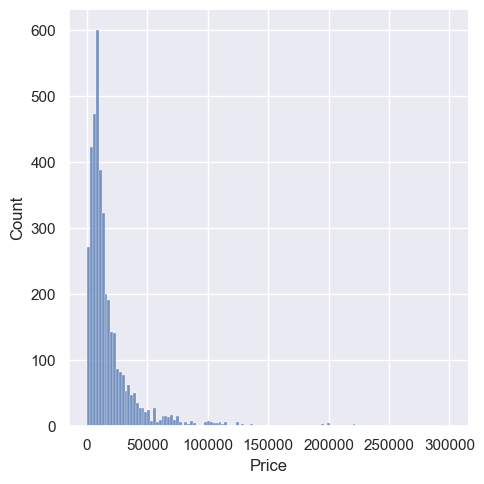

In [90]:
sns.displot(data['Price'])
data.describe(include='all')

## Removing Outliers

In [91]:

#We remove the outliers so that the prediction won't get affected coz of the outliers
q = data['Price'].quantile(0.99)
qdata = data[data['Price']<q]
qdata.describe(include='all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
count,3984,3984.000000,3984,3984.000000,3984.000000,3984,3984,3984.000000,3984
unique,7,NaN,6,NaN,NaN,4,2,NaN,302
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN,E-Class
freq,880,NaN,1528,NaN,NaN,1853,3613,NaN,188
mean,NaN,17837.117460,NaN,165.116466,2.743770,NaN,NaN,2006.292922,NaN
std,NaN,18976.268315,NaN,102.766126,4.956057,NaN,NaN,6.672745,NaN
min,NaN,600.000000,NaN,0.000000,0.600000,NaN,NaN,1969.000000,NaN
25%,NaN,6980.000000,NaN,93.000000,1.800000,NaN,NaN,2002.750000,NaN
50%,NaN,11400.000000,NaN,160.000000,2.200000,NaN,NaN,2007.000000,NaN
75%,NaN,21000.000000,NaN,230.000000,3.000000,NaN,NaN,2011.000000,NaN


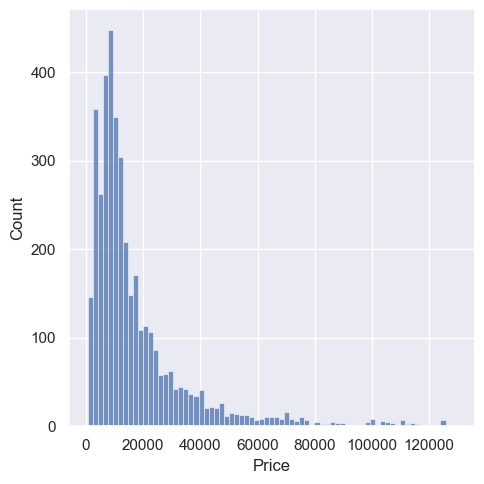

In [92]:
sns.displot(qdata['Price'])

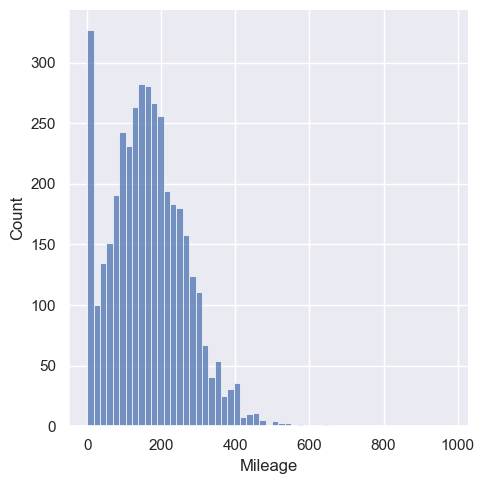

In [93]:
sns.displot(qdata['Mileage'])

In [94]:
q = qdata['Mileage'].quantile(0.99)
qdata = qdata[qdata['Mileage']<q]
qdata.describe(include='all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
count,3944,3944.000000,3944,3944.000000,3944.000000,3944,3944,3944.000000,3944
unique,7,NaN,6,NaN,NaN,4,2,NaN,299
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN,E-Class
freq,867,NaN,1511,NaN,NaN,1825,3576,NaN,185
mean,NaN,17933.880822,NaN,161.484026,2.747612,NaN,NaN,2006.389959,NaN
std,NaN,19008.212025,NaN,96.027108,4.980406,NaN,NaN,6.595986,NaN
min,NaN,600.000000,NaN,0.000000,0.600000,NaN,NaN,1969.000000,NaN
25%,NaN,7000.000000,NaN,92.000000,1.800000,NaN,NaN,2003.000000,NaN
50%,NaN,11500.000000,NaN,158.000000,2.200000,NaN,NaN,2007.000000,NaN
75%,NaN,21376.250000,NaN,230.000000,3.000000,NaN,NaN,2011.000000,NaN


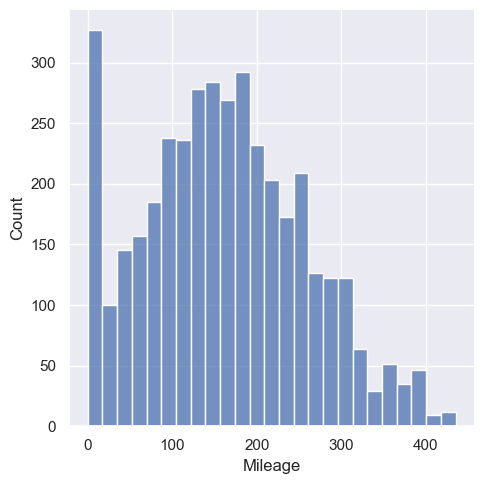

In [95]:
sns.displot(qdata['Mileage'])

In [96]:
qdata = qdata[qdata['EngineV']<6.5]
qdata

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991,320
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999,Sprinter 212
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003,S 500
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007,Q7
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011,Rav 4
...,...,...,...,...,...,...,...,...,...
4339,Toyota,17900.0,sedan,35,1.6,Petrol,yes,2014,Corolla
4340,Mercedes-Benz,125000.0,sedan,9,3.0,Diesel,yes,2014,S 350
4341,BMW,6500.0,sedan,1,3.5,Petrol,yes,1999,535
4342,BMW,8000.0,sedan,194,2.0,Petrol,yes,1985,520


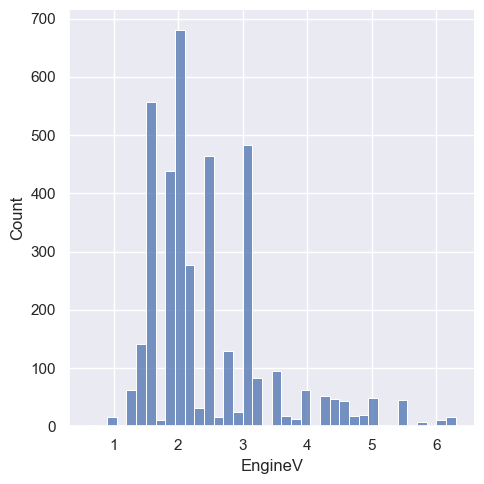

In [97]:
sns.displot(qdata['EngineV'])

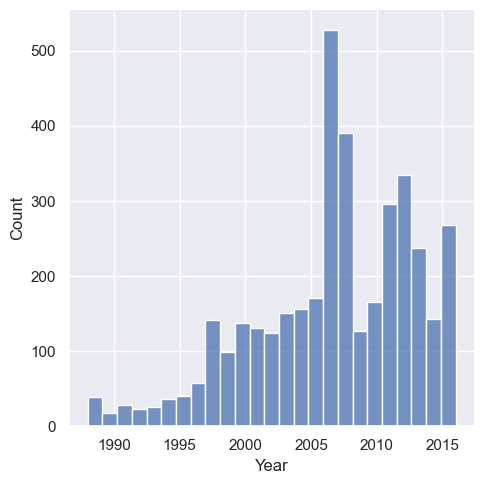

In [98]:
q = qdata['Year'].quantile(0.01)
qdata=qdata[qdata['Year']>q]
sns.displot(qdata['Year'])

In [99]:
data_cleaned = qdata.reset_index(drop=True)

In [100]:
data_cleaned.describe(include='all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
count,3867,3867.000000,3867,3867.000000,3867.000000,3867,3867,3867.000000,3867
unique,7,NaN,6,NaN,NaN,4,2,NaN,291
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN,E-Class
freq,848,NaN,1467,NaN,NaN,1807,3505,NaN,181
mean,NaN,18194.455679,NaN,160.542539,2.450440,NaN,NaN,2006.709853,NaN
std,NaN,19085.855165,NaN,95.633291,0.949366,NaN,NaN,6.103870,NaN
min,NaN,800.000000,NaN,0.000000,0.600000,NaN,NaN,1988.000000,NaN
25%,NaN,7200.000000,NaN,91.000000,1.800000,NaN,NaN,2003.000000,NaN
50%,NaN,11700.000000,NaN,157.000000,2.200000,NaN,NaN,2008.000000,NaN
75%,NaN,21700.000000,NaN,225.000000,3.000000,NaN,NaN,2012.000000,NaN


## Checking the OLS assumptions

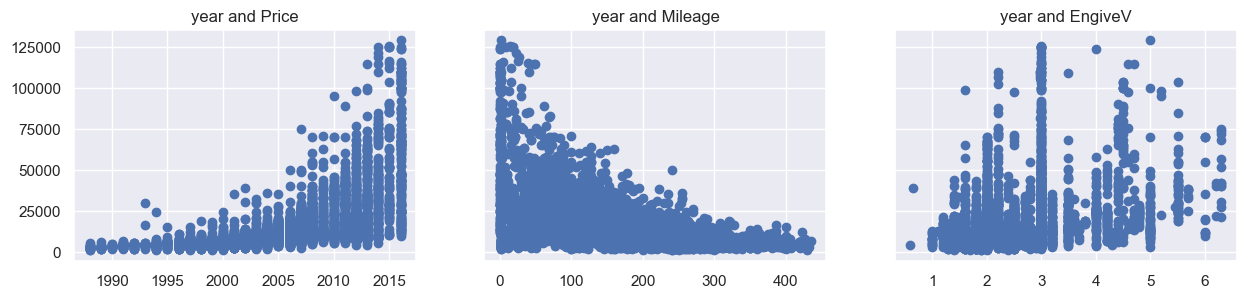

In [101]:
f,(ax1,ax2,ax3) = plt.subplots(1,3,sharey=True,figsize=(15,3))
ax1.set_title('year and Price')
ax1.scatter(data_cleaned['Year'], data_cleaned['Price'])
ax2.set_title('year and Mileage')
ax2.scatter(data_cleaned['Mileage'], data_cleaned['Price'])
ax3.set_title('year and EngiveV')
ax3.scatter(data_cleaned['EngineV'], data_cleaned['Price'])



### Relaxing the assumptions

In [102]:
data_cleaned['log_price'] = np.log(data_cleaned['Price'])

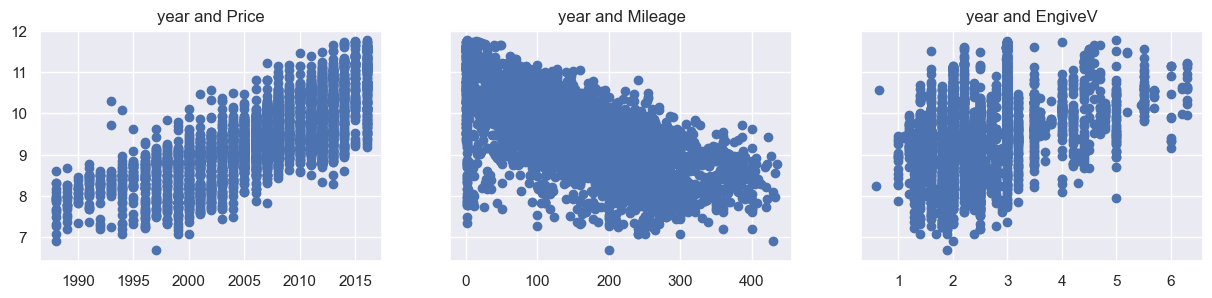

In [103]:
f,(ax1,ax2,ax3) = plt.subplots(1,3,sharey=True,figsize=(15,3))
ax1.set_title('year and Price')
ax1.scatter(data_cleaned['Year'], data_cleaned['log_price'])
ax2.set_title('year and Mileage')
ax2.scatter(data_cleaned['Mileage'], data_cleaned['log_price'])
ax3.set_title('year and EngiveV')
ax3.scatter(data_cleaned['EngineV'], data_cleaned['log_price'])


### Checking Multicollinearity

In [104]:
data_cleaned.columns.values

<StringArray>
[       'Brand',        'Price',         'Body',      'Mileage',
      'EngineV',  'Engine Type', 'Registration',         'Year',
        'Model',    'log_price']
Length: 10, dtype: str

In [105]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
variables = data_cleaned[["Mileage","Year","EngineV"]]
VIF = pd.DataFrame()
VIF["VIF"] = [vif(variables.values,i) for i in range(variables.shape[1])]
VIF['features'] = variables.columns
VIF


,VIF,features
0,3.791584,Mileage
1,10.354854,Year
2,7.662068,EngineV


In [106]:
vif

<function statsmodels.stats.outliers_influence.variance_inflation_factor(exog, exog_idx)>

In [107]:
data_no_col = data_cleaned.drop(columns="Year")
data_no_col

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Model,log_price
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,320,8.342840
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,Sprinter 212,8.974618
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,S 500,9.495519
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,Q7,10.043249
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,Rav 4,9.814656
...,...,...,...,...,...,...,...,...,...
3862,Volkswagen,11500.0,van,163,2.5,Diesel,yes,T5 (Transporter),9.350102
3863,Toyota,17900.0,sedan,35,1.6,Petrol,yes,Corolla,9.792556
3864,Mercedes-Benz,125000.0,sedan,9,3.0,Diesel,yes,S 350,11.736069
3865,BMW,6500.0,sedan,1,3.5,Petrol,yes,535,8.779557


Here we are encoding the model column with the mean price of that particular model. For Example, For BMW 320, we calculate the mean price of all 320 models in the list. We do this by grouping by the table based on model and then calculating the mean.
    

In [108]:
data_no_col

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Model,log_price
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,320,8.342840
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,Sprinter 212,8.974618
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,S 500,9.495519
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,Q7,10.043249
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,Rav 4,9.814656
...,...,...,...,...,...,...,...,...,...
3862,Volkswagen,11500.0,van,163,2.5,Diesel,yes,T5 (Transporter),9.350102
3863,Toyota,17900.0,sedan,35,1.6,Petrol,yes,Corolla,9.792556
3864,Mercedes-Benz,125000.0,sedan,9,3.0,Diesel,yes,S 350,11.736069
3865,BMW,6500.0,sedan,1,3.5,Petrol,yes,535,8.779557


In [109]:
data_no_col.columns.values

<StringArray>
[       'Brand',        'Price',         'Body',      'Mileage',
      'EngineV',  'Engine Type', 'Registration',        'Model',
    'log_price']
Length: 9, dtype: str

## Create dummy variables

In [110]:
data_w_dum = pd.get_dummies(data_no_col,drop_first = True,dtype=int, columns=['Brand','Body', 'Engine Type'])
data_w_dum

,Price,Mileage,EngineV,Registration,Model,log_price,Brand_BMW,Brand_Mercedes-Benz,Brand_Mitsubishi,Brand_Renault,Brand_Toyota,Brand_Volkswagen,Body_hatch,Body_other,Body_sedan,Body_vagon,Body_van,Engine Type_Gas,Engine Type_Other,Engine Type_Petrol
0,4200.0,277,2.0,yes,320,8.342840,1,0,0,0,0,0,0,0,1,0,0,0,0,1
1,7900.0,427,2.9,yes,Sprinter 212,8.974618,0,1,0,0,0,0,0,0,0,0,1,0,0,0
2,13300.0,358,5.0,yes,S 500,9.495519,0,1,0,0,0,0,0,0,1,0,0,1,0,0
3,23000.0,240,4.2,yes,Q7,10.043249,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,18300.0,120,2.0,yes,Rav 4,9.814656,0,0,0,0,1,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3862,11500.0,163,2.5,yes,T5 (Transporter),9.350102,0,0,0,0,0,1,0,0,0,0,1,0,0,0
3863,17900.0,35,1.6,yes,Corolla,9.792556,0,0,0,0,1,0,0,0,1,0,0,0,0,1
3864,125000.0,9,3.0,yes,S 350,11.736069,0,1,0,0,0,0,0,0,1,0,0,0,0,0
3865,6500.0,1,3.5,yes,535,8.779557,1,0,0,0,0,0,0,0,1,0,0,0,0,1


In [111]:
data_w_dum.head()


,Price,Mileage,EngineV,Registration,Model,log_price,Brand_BMW,Brand_Mercedes-Benz,Brand_Mitsubishi,Brand_Renault,Brand_Toyota,Brand_Volkswagen,Body_hatch,Body_other,Body_sedan,Body_vagon,Body_van,Engine Type_Gas,Engine Type_Other,Engine Type_Petrol
0,4200.0,277,2.0,yes,320,8.342840,1,0,0,0,0,0,0,0,1,0,0,0,0,1
1,7900.0,427,2.9,yes,Sprinter 212,8.974618,0,1,0,0,0,0,0,0,0,0,1,0,0,0
2,13300.0,358,5.0,yes,S 500,9.495519,0,1,0,0,0,0,0,0,1,0,0,1,0,0
3,23000.0,240,4.2,yes,Q7,10.043249,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,18300.0,120,2.0,yes,Rav 4,9.814656,0,0,0,0,1,0,0,0,0,0,0,0,0,1


### Rearrange a bit

In [112]:
data_w_dum.columns

Index(['Price', 'Mileage', 'EngineV', 'Registration', 'Model', 'log_price',
       'Brand_BMW', 'Brand_Mercedes-Benz', 'Brand_Mitsubishi', 'Brand_Renault',
       'Brand_Toyota', 'Brand_Volkswagen', 'Body_hatch', 'Body_other',
       'Body_sedan', 'Body_vagon', 'Body_van', 'Engine Type_Gas',
       'Engine Type_Other', 'Engine Type_Petrol'],
      dtype='str')

In [113]:
data_rearranged = data_w_dum[['log_price','Price', 'Mileage', 'EngineV', 'Registration', 'Model',
       'Brand_BMW', 'Brand_Mercedes-Benz', 'Brand_Mitsubishi', 'Brand_Renault',
       'Brand_Toyota', 'Brand_Volkswagen', 'Body_hatch', 'Body_other',
       'Body_sedan', 'Body_vagon', 'Body_van', 'Engine Type_Gas',
       'Engine Type_Other', 'Engine Type_Petrol']]
data_rearranged.head()

,log_price,Price,Mileage,EngineV,Registration,Model,Brand_BMW,Brand_Mercedes-Benz,Brand_Mitsubishi,Brand_Renault,Brand_Toyota,Brand_Volkswagen,Body_hatch,Body_other,Body_sedan,Body_vagon,Body_van,Engine Type_Gas,Engine Type_Other,Engine Type_Petrol
0,8.342840,4200.0,277,2.0,yes,320,1,0,0,0,0,0,0,0,1,0,0,0,0,1
1,8.974618,7900.0,427,2.9,yes,Sprinter 212,0,1,0,0,0,0,0,0,0,0,1,0,0,0
2,9.495519,13300.0,358,5.0,yes,S 500,0,1,0,0,0,0,0,0,1,0,0,1,0,0
3,10.043249,23000.0,240,4.2,yes,Q7,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,9.814656,18300.0,120,2.0,yes,Rav 4,0,0,0,0,1,0,0,0,0,0,0,0,0,1


***

In [114]:
data_for_vif = data_rearranged.drop(columns=["log_price",'Model','Registration'])
data_for_vif.head()

,Price,Mileage,EngineV,Brand_BMW,Brand_Mercedes-Benz,Brand_Mitsubishi,Brand_Renault,Brand_Toyota,Brand_Volkswagen,Body_hatch,Body_other,Body_sedan,Body_vagon,Body_van,Engine Type_Gas,Engine Type_Other,Engine Type_Petrol
0,4200.0,277,2.0,1,0,0,0,0,0,0,0,1,0,0,0,0,1
1,7900.0,427,2.9,0,1,0,0,0,0,0,0,0,0,1,0,0,0
2,13300.0,358,5.0,0,1,0,0,0,0,0,0,1,0,0,1,0,0
3,23000.0,240,4.2,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,18300.0,120,2.0,0,0,0,0,1,0,0,0,0,0,0,0,0,1


In [115]:
x = pd.DataFrame()
x['VIF'] = [vif(data_for_vif.values,i) for i in range(data_for_vif.shape[1])]
x['features'] = data_for_vif.columns
x

,VIF,features
0,3.554962,Price
1,6.077720,Mileage
2,10.344461,EngineV
3,2.303556,Brand_BMW
4,2.834272,Brand_Mercedes-Benz
5,1.478981,Brand_Mitsubishi
6,1.814995,Brand_Renault
7,1.985066,Brand_Toyota
8,2.529727,Brand_Volkswagen
9,1.434987,Body_hatch


In [116]:
data_rearranged['Registration_No'] = data_rearranged['Registration'].map({'yes':1, 'no':0})
data_rearranged.drop(columns='Registration',inplace=True)

In [117]:
from sklearn.model_selection import train_test_split
x = data_rearranged.drop(columns='log_price')
y = data_rearranged['log_price']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state=35)

## MEAN ENCODING FOR MODEL

We created a new column called model_encoding which has the average price of the model thats already given to us, For eg. If we take BMW 320, we calculate the average price of that model and use that for predicting. We do train_test_split and use this trick only for training data.

If we have a new model in test, we will use the global mean of all cars for that model.

In [118]:
model_means = y_train.groupby(x_train['Model']).mean()
x_train['Model_Encoded'] = x_train['Model'].map(model_means)
x_test['Model_Encoded'] = x_train['Model'].map(model_means)


In [119]:
global_mean = y_train.mean()
x_test['Model_Encoded'] = x_test['Model_Encoded'].fillna(global_mean)
x_test

,Price,Mileage,EngineV,Model,Brand_BMW,Brand_Mercedes-Benz,Brand_Mitsubishi,Brand_Renault,Brand_Toyota,Brand_Volkswagen,Body_hatch,Body_other,Body_sedan,Body_vagon,Body_van,Engine Type_Gas,Engine Type_Other,Engine Type_Petrol,Registration_No,Model_Encoded
2795,10500.0,93,1.5,Duster,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,9.422243
1177,8999.0,270,2.8,528,1,0,0,0,0,0,0,0,1,0,0,0,0,1,1,9.422243
2478,3250.0,250,4.0,S 400,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,9.422243
694,17500.0,125,3.0,530,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,9.422243
482,12600.0,205,2.4,Camry,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,9.422243
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2873,2300.0,189,1.8,318,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,9.422243
2244,14990.0,135,2.5,525,1,0,0,0,0,0,0,0,1,0,0,0,0,1,1,9.422243
2516,3400.0,175,1.4,Caddy,0,0,0,0,0,1,0,0,0,0,1,0,0,1,1,9.422243
2718,10200.0,120,2.0,A4,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,9.422243


In [120]:
x_train = x_train.drop(columns=['Model'])
x_test = x_test.drop(columns=['Model'])

In [121]:
x_train.columns

Index(['Price', 'Mileage', 'EngineV', 'Brand_BMW', 'Brand_Mercedes-Benz',
       'Brand_Mitsubishi', 'Brand_Renault', 'Brand_Toyota', 'Brand_Volkswagen',
       'Body_hatch', 'Body_other', 'Body_sedan', 'Body_vagon', 'Body_van',
       'Engine Type_Gas', 'Engine Type_Other', 'Engine Type_Petrol',
       'Registration_No', 'Model_Encoded'],
      dtype='str')

## Calculating Variance Inflation Factor for all dummies

In [122]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
variables = x_train[['Mileage', 'Body_hatch', 'Body_other', 'Body_sedan', 'Body_vagon', 'Body_van',
       'Engine Type_Gas', 'Engine Type_Other', 'Engine Type_Petrol', 'Model_Encoded']]
vif = pd.DataFrame()
vif['Features'] = variables.columns
vif['VIF'] = [variance_inflation_factor(variables.values,i) for i in range(variables.shape[1])]
vif

,Features,VIF
0,Mileage,4.149426
1,Body_hatch,1.330661
2,Body_other,1.457938
3,Body_sedan,3.022358
4,Body_vagon,1.483727
5,Body_van,1.890740
6,Engine Type_Gas,1.475546
7,Engine Type_Other,1.081439
8,Engine Type_Petrol,2.332523
9,Model_Encoded,6.230328


## Training the Model

In [123]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [124]:
reg.score(x_train,y_train)

0.8848494353026614

In [130]:
x_test

,Price,Mileage,EngineV,Brand_BMW,Brand_Mercedes-Benz,Brand_Mitsubishi,Brand_Renault,Brand_Toyota,Brand_Volkswagen,Body_hatch,Body_other,Body_sedan,Body_vagon,Body_van,Engine Type_Gas,Engine Type_Other,Engine Type_Petrol,Registration_No,Model_Encoded
2795,10500.0,93,1.5,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,9.422243
1177,8999.0,270,2.8,1,0,0,0,0,0,0,0,1,0,0,0,0,1,1,9.422243
2478,3250.0,250,4.0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,9.422243
694,17500.0,125,3.0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,9.422243
482,12600.0,205,2.4,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,9.422243
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2873,2300.0,189,1.8,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,9.422243
2244,14990.0,135,2.5,1,0,0,0,0,0,0,0,1,0,0,0,0,1,1,9.422243
2516,3400.0,175,1.4,0,0,0,0,0,1,0,0,0,0,1,0,0,1,1,9.422243
2718,10200.0,120,2.0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,9.422243


In [131]:
y_hat = reg.predict(x_test)
y_test = pd.DataFrame(y_test)


## Graphical Representation of the Model

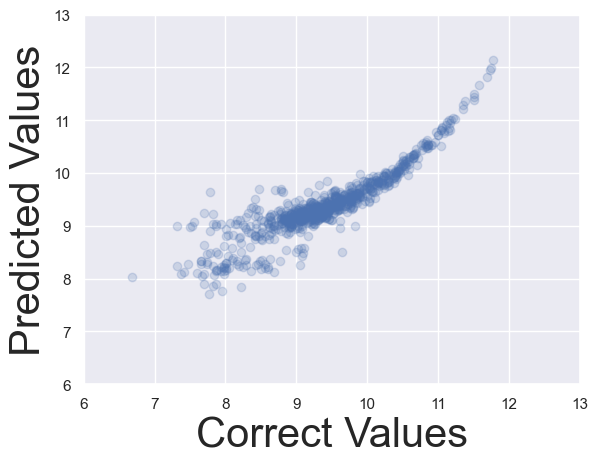

In [133]:
plt.scatter(y_test,y_hat,alpha=0.2)
plt.xlabel("Correct Values", fontsize=30)
plt.ylabel("Predicted Values", fontsize= 30)
plt.xlim(6,13)
plt.ylim(6,13)
plt.show()


In [ ]:
len(y_test)

## Comparing the Predicted and Actual Values

In [134]:
df_pf = pd.DataFrame(np.exp(y_hat),columns=["Predictions"])
y_test = y_test.reset_index(drop=True)

y_test

,log_price
0,9.259131
1,9.104869
2,8.086410
3,9.769956
4,9.441452
...,...
769,7.740664
770,9.615139
771,8.131531
772,9.230143


In [135]:
df_pf['Actual Price'] = np.exp(y_test['log_price'])
df_pf.head()

,Predictions,Actual Price
0,11281.887815,10500.0
1,9368.181315,8999.0
2,4268.667528,3250.0
3,17336.730416,17500.0
4,10304.245051,12600.0


## Creating Summary Table

In [136]:
df_pf['Residual'] = df_pf['Actual Price'] - df_pf['Predictions']
df_pf["Difference%"] = np.absolute(df_pf['Residual']/df_pf['Actual Price'] * 100)
df_pf.describe(include='all')

,Predictions,Actual Price,Residual,Difference%
count,774.000000,774.000000,774.000000,774.000000
mean,15161.022717,17154.385736,1993.363020,33.781364
std,15817.630307,17358.728423,6151.672800,48.079586
min,2208.931596,800.000000,-58157.326618,0.202069
25%,8994.442992,7325.000000,-1530.133230,13.119159
50%,11273.152250,11650.000000,908.357953,23.500002
75%,15649.862649,19669.060000,4790.870618,34.010373
max,187379.326618,129222.000000,25080.011452,537.956602


## Residual Graph

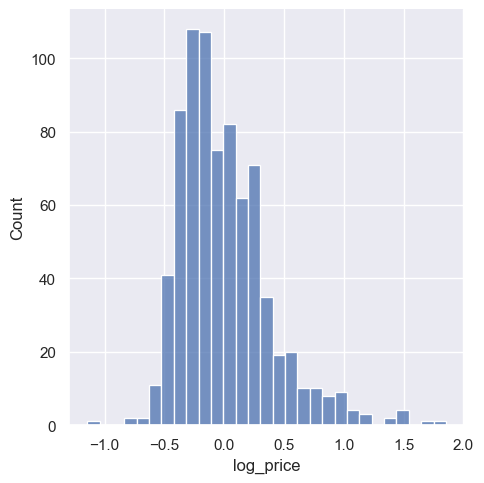

In [145]:
sns.displot(y_hat-y_test.iloc[:,0])

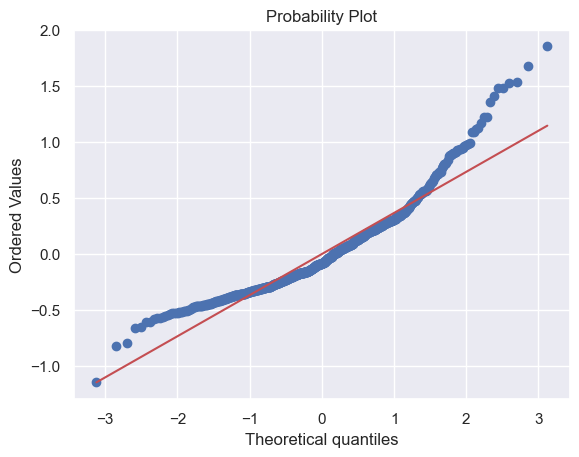

In [146]:
import scipy.stats as stats
stats.probplot(y_hat - y_test.iloc[:,0], dist="norm", plot=plt)
plt.show()

Mean encoding was applied to the model feature by creating a new column model_encoding, which represents the average price for each car model. This helped the model capture the relationship between car models and their typical prices more effectively.

After introducing this feature, the model performance improved significantly. The R² score increased from ~0.70 to 0.8848, indicating that the model now explains about 88% of the variance in car prices.

Residual analysis was performed using a distribution plot and Q-Q plot. The residuals are centered around zero and approximately follow a normal distribution, suggesting that the model predictions are reasonably unbiased with some deviation in the tails due to outliers.

Overall, mean encoding improved the model’s predictive power and reduced prediction error compared to using the raw categorical feature.
